## Models Info

In [4]:
# sub models info
import numpy as np

ai_questions_map = {'AI_1': 'I believe AI will improve my life',
                    'AI_2': 'I believe that AI will improve my work',
                    'AI_3': 'I think I will use AI technology in the future',
                    'AI_4': 'I think AI technology is a threat to humans',
                    'AI_5': 'I think AI technology is positive for humanity',
                    'ES_understandable': 'The explanations of the agent’s paths were clear and easy to understand',
                    'ES_2': 'This is an attention check question, please select "Strongly agree"',
                    'ES_overwhelming': 'The explanations felt too detailed and overwhelming',
                    'ES_feedback_contribution': 'The explanations helped me see how my feedback changed the agent’s behavior',
                    'ES_helpful': 'The visual demonstrations of policy changes helped understand the differences between agents',
                }


In [5]:
from pandas import DataFrame
import pandas as pd


saved_df = "results/dpu_results_choices.csv"
choice_results = pd.read_csv(saved_df)

user_results_path = 'results/dpu_results_users.csv'
user_results = pd.read_csv(user_results_path)



# # Apply column renames per spec
# user_results = user_results.rename(columns={
#     'Trust_the_agent': 'trust_the_agent',
#     'number_of_good_choices': 'number_of_correct_choices_mean',
#     'number_of_good_choices_last': 'number_of_correct_choices_feedback',
#     'final_agent_score': 'final_agent_mean_score',
#     'familiarity_with_AI': 'familiar_with_AI',
#     'evaluate_AI': 'evaluate_final_agent',
#     'SS_1': 'ES_understandable',
#     'SS_3': 'ES_overwhelming',
#     'SS_4': 'ES_feedback_related',
#     'SS_5': 'ES_helpful',
#     'SS_mean': 'ES_combined',
#     'similarity_level': 'group'
# })

# choice_results = choice_results.rename(columns={
#     'similarity_level': 'group',
#     'good_choice': 'correct_choice_generalized',
#     'good_choice_last': 'correct_choice_feedback',
#     'choice': 'choice_to_update',
#     'update_agent': 'updated_agent',
#     'Trust_the_agent': 'trust_the_agent',
#     'prev_agent_last_score': 'prev_agent_feedback_score',
#     'update_agent_last_score': 'updated_agent_feedback_score',
#     'improved_from_prev_last': 'improved_from_prev_feedback',
#     'final_agent_score': 'final_agent_mean_score',
# })

## check the data

In [6]:
user_results.columns

Index(['user_id', 'group', 'trust_the_agent', 'number_of_choices',
       'number_of_accepts', 'number_of_correct_choices_mean',
       'number_of_correct_choices_feedback', 'final_agent_mean_score',
       'final_agent_name', 'final_agent_rank', 'final_agent_final_part_score',
       'age', 'gender', 'education', 'familiar_with_AI',
       'evaluate_final_agent', 'ES_understandable', 'ES_overwhelming',
       'ES_feedback_contribution', 'ES_helpful', 'ES_combined'],
      dtype='object')

In [7]:
user_results['final_agent_name'].value_counts()

final_agent_name
NoRedLH1_0612        87
AllColorsLH_0617     72
OnlyBlueLH_0706      65
OnlyBlueLL_0625      28
AllColorsLL1_0526    17
OnlyGreenLL_0429     11
Name: count, dtype: int64

In [8]:
user_results['group'].value_counts()

group
Random              76
Salient-Contrast    73
Control             69
Same                62
Name: count, dtype: int64

In [9]:
user_results.columns

Index(['user_id', 'group', 'trust_the_agent', 'number_of_choices',
       'number_of_accepts', 'number_of_correct_choices_mean',
       'number_of_correct_choices_feedback', 'final_agent_mean_score',
       'final_agent_name', 'final_agent_rank', 'final_agent_final_part_score',
       'age', 'gender', 'education', 'familiar_with_AI',
       'evaluate_final_agent', 'ES_understandable', 'ES_overwhelming',
       'ES_feedback_contribution', 'ES_helpful', 'ES_combined'],
      dtype='object')

In [10]:
choice_results.columns

Index(['user_id', 'episode', 'group', 'trust_the_agent', 'prev_agent',
       'updated_agent', 'prev_agent_mean_score', 'update_agent_mean_score',
       'prev_agent_feedback_score', 'updated_agent_feedback_score',
       'choice_to_update', 'correct_choice_generalized',
       'correct_choice_feedback', 'choice_time', 'improved_from_prev_feedback',
       'improved_from_prev_mean'],
      dtype='object')

# Start Ploting

### Ploting Methods

In [11]:
print(sorted(choice_results['group'].unique()))

['Control', 'Random', 'Salient-Contrast', 'Same']


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'] 
group_names = ['Control', 'Random', 'Same', 'Salient-Contrast']


# Configure matplotlib for Jupyter notebook - use inline backend
%matplotlib inline


def plot_simple_bar_plot(df, 
    x_col, 
    y_col, 
    x_val_names=None, 
    figsize=(8, 6), 
    estimator=lambda x: np.mean(x) * 100, 
    errorbar=('ci', 95), 
    palette=None, 
    title=None, 
    x_label='Group', 
    y_label='Correct Choice',
    aggfunc='sum',
    from_total_agg = True,
    only_total_agg= False,
    percentage_agg = False,
    order=None,
    debug_print=False,
    bar_label_fmt='%.1f%%',
    save_path=None,
):
    if order is None:
        order = sorted(df[x_col].unique())
    if debug_print:
        print(order)
    ax = sns.barplot(
        data=df,
        x=x_col,
        y=y_col,
        estimator=estimator,  # Convert to percentage
        palette=palette,
        order=order,
        errorbar=errorbar
    )

    # Compute counts per similarity level once
    counts = (
        df
        .groupby(x_col)[y_col]
        .agg(total='size', good=aggfunc)
        .reindex(order)
    )

    if debug_print:
        print(counts)
    if percentage_agg:
        for container in ax.containers:
            ax.bar_label(container, fmt=bar_label_fmt, label_type='edge', fontsize=13)#, fontweight='bold')
    else:
        if from_total_agg:
            labels = [f"   {int(counts.loc[level, 'good'])}/{int(counts.loc[level, 'total'])}" for level in list(counts.index) if level is not np.nan]
        elif only_total_agg:
            labels = [f"n={int(counts.loc[level, 'total'])}" for level in list(counts.index)  if level is not np.nan]
        else:
            labels = [f"{int(counts.loc[level, 'good'])}" for level in list(counts.index)  if level is not np.nan]
        # Annotate all the bars in the plot
        for container, label in zip(ax.containers, labels):
            ax.bar_label(container, labels=[label] * len(container), label_type='edge', fontsize=12)#, fontweight='bold')

    plt.xlabel(x_label if x_label else x_col, fontsize=14)
    plt.ylabel(y_label if y_label else y_col, fontsize=14)
    plt.yticks(fontsize=13)
    # plt.title(title if title else f'{y_col} percentage by {x_col}')
    if not x_val_names:
        x_val_names = [str(level) for level in order]
    if x_val_names:
        # if len(x_val_names[0]) > 12:
        #     ax.set_xticklabels(x_val_names, rotation=40, ha='right')
        # else:
        ax.set_xticklabels(x_val_names, fontsize=13)
    
    
    if save_path:
        from pathlib import Path
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight')

    plt.show()


In [13]:
def plot_grouped_barplot(
    df, 
    x_col, 
    y_col, 
    hue=None, 
    hue_names=None,
    x_val_names=None, 
    figsize=(8, 6), 
    estimator=lambda x: np.mean(x) * 100, 
    errorbar=('ci', 95),
    from_total_agg=True,
    percentage_agg = False,
    aggfunc='sum',
    palette=None,
    title=None,
    x_label='Group', 
    y_label='Correct Choice %',
    order=None,
    hue_title=None,
    bar_label_fmt='%.1f%%',
    bottom_start=0,
    ylim_bottom=0,
    save_path=None,
):
    """
    Plots a grouped barplot with annotated counts for each bar.

    Parameters:
        df (pd.DataFrame): DataFrame to plot.
        x_col (str): Column for x-axis.
        y_col (str): Column for y-axis (should be numeric/binary for mean).
        hue (str, optional): Column for grouping bars. Default: None.
        x_val_names (list, optional): Custom x-tick labels.
        figsize (tuple): Figure size.
        estimator (callable): Function to aggregate y_col (default: mean*100).
        errorbar (str): Error bar type for seaborn.
        palette (list, optional): Colors for bars.
        x_label (str, optional): X-axis label.
        y_label (str, optional): Y-axis label.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    if order is None:
        order = sorted(list(df[x_col].unique()))

    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue,
        estimator=estimator,
        errorbar=errorbar,
        palette=palette,
        order=order
    )

    if percentage_agg:
        for container in ax.containers:
            ax.bar_label(container, fmt=bar_label_fmt, label_type='edge', fontsize=12)#, fontweight='bold')
    else:
        print(df.columns)
        grouped = (
            df
            .groupby([x_col, hue])[y_col]
            .agg(total='size', good=aggfunc)
            .reset_index()
        )
        counts = grouped.set_index([x_col, hue]).unstack(hue)  # MultiIndex columns: ('total', hue), ('good', hue)
        counts = counts.reindex(order)  # reorder by x levels

        levels_in_plot = list(counts.index)
        labels = []
        for group in counts['good'].columns:  # iterate hue values
            level_labels = []
            for level in levels_in_plot:
                good = counts['good'].get(group).get(level)
                total = counts['total'].get(group).get(level)
                if not pd.isna(good) and not pd.isna(total):
                    level_labels.append(f"{int(good)}/{int(total)}" if from_total_agg else f"{int(good)}")
            labels.append(level_labels)
        print(labels)
        for container, level_labels in zip(ax.containers, labels):
            ax.bar_label(container, labels=level_labels, label_type='edge', fontsize=11, fontweight='bold')

    hue_title_map = {'improved_from_prev_feedback': 'Better than Previous agent (Feedback)',
                     'improved_from_base_last': 'Better than Base agent (Feedback)',
                     'improved_from_prev_mean': 'Better than Previous agent (Mean score)',
                     'improved_from_base': 'Better than Base agent (Mean score)'
                     }
    if not x_val_names:
        x_val_names = sorted([str(level) for level in order])
    if len(x_val_names[0]) > 15:
        ax.set_xticklabels(x_val_names, rotation=40, ha='right', fontsize=11)
    else:
        print("setting x labels:", x_val_names)
        ax.set_xticklabels(x_val_names, fontsize=13)
    if x_label:
        plt.xlabel(x_label, fontsize=14)
    if y_label:
        plt.ylabel(y_label, fontsize=14)
    
    plt.yticks(fontsize=13)

    if not hue_names:
        hue_names = sorted(list(df[hue].unique()))
    if not hue_title:
        hue_title = hue_title_map.get(hue, hue)
    handles, labels = ax.get_legend_handles_labels()
    # Support list or dict mapping for custom names
    if isinstance(hue_names, dict):
        display_labels = [hue_names.get(lbl, lbl) for lbl in labels]
    else:
        display_labels = hue_names

    ax.legend(handles=handles, labels=display_labels, fontsize=11) #, title=hue_title
    plt.ylim(bottom=ylim_bottom)
    if save_path:
        from pathlib import Path
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight')

    
    plt.show()




In [14]:
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'] 
group_names = ['Control', 'Random', 'Same', 'Salient-Contrast']


# Configure matplotlib for Jupyter notebook - use inline backend
%matplotlib inline
def plot_barplot(
    df, 
    x_col, 
    y_col, 
    hue=None, 
    hue_names=None,
    x_val_names=None, 
    figsize=(8, 6), 
    estimator=lambda x: np.mean(x) * 100, 
    errorbar=('ci', 95),
    palette=None,
    x_label='Group', 
    y_label='Correct Choice %',
    order=None,
    bar_label_fmt='%.1f%%',
    ylim_bottom=0,
    save_path=None,
):
    """
    Plots a grouped barplot with annotated counts for each bar.

    Parameters:
        df (pd.DataFrame): DataFrame to plot.
        x_col (str): Column for x-axis.
        y_col (str): Column for y-axis (should be numeric/binary for mean).
        hue (str, optional): Column for grouping bars. Default: None.
        x_val_names (list, optional): Custom x-tick labels.
        figsize (tuple): Figure size.
        estimator (callable): Function to aggregate y_col (default: mean*100).
        errorbar (str): Error bar type for seaborn.
        palette (list, optional): Colors for bars.
        x_label (str, optional): X-axis label.
        y_label (str, optional): Y-axis label.
    """
    if order is None:
        order = sorted(list(df[x_col].unique()))

    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue,
        estimator=estimator,
        errorbar=errorbar,
        palette=palette,
        order=order
    )

    for container in ax.containers:
        ax.bar_label(container, fmt=bar_label_fmt, label_type='edge', fontsize=12)#, fontweight='bold')

    if not x_val_names:
        x_val_names = sorted([str(level) for level in order])
    if len(x_val_names[0]) > 15:
        ax.set_xticklabels(x_val_names, rotation=40, ha='right', fontsize=11)
    else:
        ax.set_xticklabels(x_val_names, fontsize=13)
    if x_label:
        plt.xlabel(x_label, fontsize=14)
    if y_label:
        plt.ylabel(y_label, fontsize=14)
    plt.yticks(fontsize=13)

    handles, labels = ax.get_legend_handles_labels()
    if hue:
        if not hue_names:
            hue_names = sorted(list(df[hue].unique()))
        
        if isinstance(hue_names, dict):
            display_labels = [hue_names.get(lbl, lbl) for lbl in labels]
        else:
            display_labels = hue_names
        
        ax.legend(handles=handles, labels=display_labels, fontsize=11)
    plt.ylim(bottom=ylim_bottom)

    if save_path:
        from pathlib import Path
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight')

    plt.show()




In [15]:
from scipy.stats import mannwhitneyu
import itertools

def mannwhitneyu_test(df, y_col, x_col, test_type='two-sided'):
    # Prepare data
    levels = sorted(df[x_col].unique())
    results = []

    for lvl1, lvl2 in itertools.combinations(levels, 2):
        group1 = df[df[x_col] == lvl1][y_col]
        group2 = df[df[x_col] == lvl2][y_col]
        stat, p = mannwhitneyu(group1, group2, alternative=test_type)
        results.append({'level_1': lvl1, 'level_2': lvl2, 'U': stat, 'p_value': p})

    # Convert results to DataFrame for easy viewing
    mannwhitney_results_df = pd.DataFrame(results)
    print(mannwhitney_results_df)



### Basic Good Choice percentage

In [16]:
user_results['final_agent_name'].value_counts()

final_agent_name
NoRedLH1_0612        87
AllColorsLH_0617     72
OnlyBlueLH_0706      65
OnlyBlueLL_0625      28
AllColorsLL1_0526    17
OnlyGreenLL_0429     11
Name: count, dtype: int64

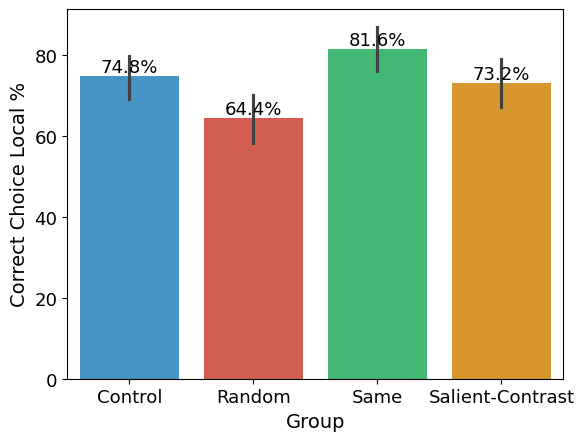

            level_1           level_2        U   p_value
0           Control            Random  33718.5  0.012215
1           Control  Salient-Contrast  26153.0  0.697525
2           Control              Same  21916.5  0.088393
3            Random  Salient-Contrast  26179.5  0.038564
4            Random              Same  21712.5  0.000046
5  Salient-Contrast              Same  20250.5  0.040229


In [17]:
plot_simple_bar_plot(choice_results, 
                     'group', 
                     'correct_choice_feedback', 
                     title='Correct Choice (Local) by Group',
                     y_label='Correct Choice Local %',
                     palette=colors_palette,
                     from_total_agg=False,
                     percentage_agg=True,
                     save_path='images/correct_choice_local_by_group.pdf',
                     order=group_names,
                     x_val_names=group_names
                     )

mannwhitneyu_test(choice_results, 'correct_choice_feedback', 'group', 'two-sided')

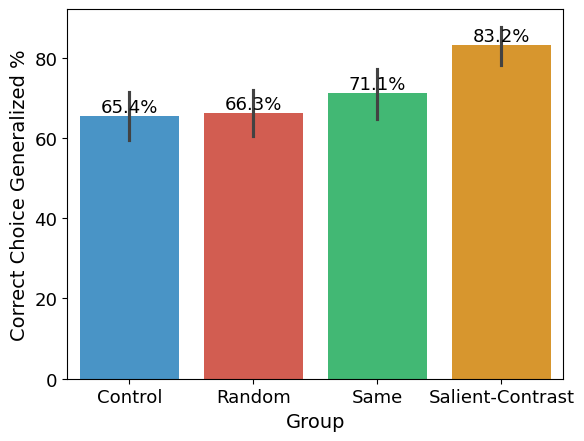

Mann-Whitney U Test Results for Correct Choice (Generalized) by Group
            level_1           level_2        U   p_value
0           Control            Random  30262.5  0.833689
1           Control  Salient-Contrast  21159.0  0.000016
2           Control              Same  22162.5  0.199691
3            Random  Salient-Contrast  23858.5  0.000026
4            Random              Same  24955.5  0.265943
5  Salient-Contrast              Same  24771.5  0.003206


In [18]:
plot_simple_bar_plot(choice_results, 
                     'group', 
                     'correct_choice_generalized', 
                     title='Correct Choice (Generalized) by Group', 
                     palette=colors_palette,
                     from_total_agg=False,
                     percentage_agg=True,
                     y_label='Correct Choice Generalized %',
                     order=group_names,
                     x_val_names=group_names,
                     save_path='images/correct_choice_generalized_by_group.pdf'
                     )

print("Mann-Whitney U Test Results for Correct Choice (Generalized) by Group")
mannwhitneyu_test(choice_results, 'correct_choice_generalized', 'group')

setting x labels: ['Negative', 'Positive']


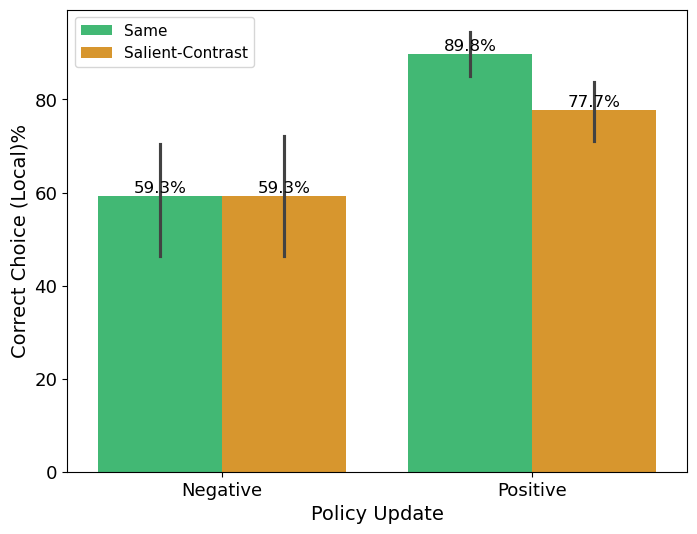

Mann-Whitney U Test Results for Improved from Previous Agent (Local) by Group
            level_1 level_2        U   p_value
0  Salient-Contrast    Same  10726.5  0.004218


In [19]:
plot_df = choice_results[choice_results['group'].isin(group_names[2:4])].copy()
# print(plot_df)
plot_grouped_barplot(plot_df,
                     x_col='improved_from_prev_feedback',
                     y_col='correct_choice_feedback',
                     y_label='Correct Choice (Local)%',
                     x_label='Policy Update',
                     x_val_names=['Negative', 'Positive'],
                     hue='group',
                     hue_names=list(plot_df['group'].unique()),
                    title='Correct Choice (Local) by Update Direction Contrast vs Same',
                    percentage_agg=True,
                    palette=colors_palette[2:],
                    hue_title='Group',
                    save_path='images/correct_choice_local_by_update_direction_contrast_vs_same.pdf'

)

print("Mann-Whitney U Test Results for Improved from Previous Agent (Local) by Group")
mannwhitneyu_test(plot_df[plot_df['improved_from_prev_feedback'] == 1], 'correct_choice_feedback', 'group')

setting x labels: ['Negative', 'Positive']


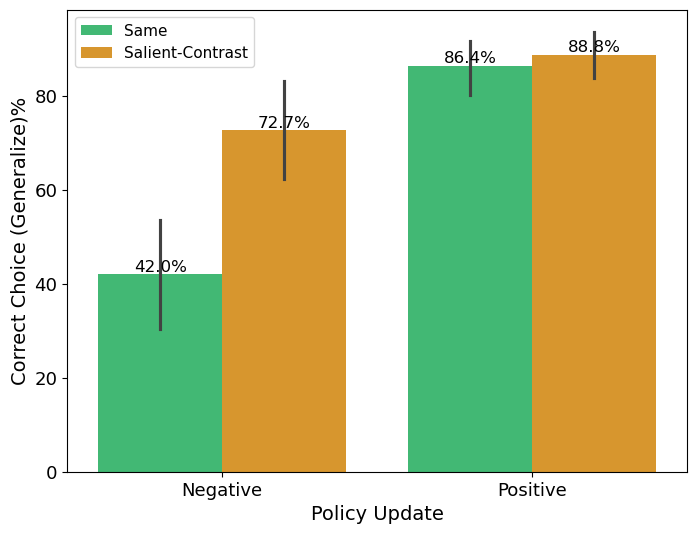

Mann-Whitney U Test Results for Improved from Previous Agent (Generalize) by Group
            level_1 level_2       U   p_value
0  Salient-Contrast    Same  3472.0  0.000184


In [20]:
plot_df = choice_results[choice_results['group'].isin(group_names[2:4])].copy()
plot_grouped_barplot(plot_df,
                     x_col='improved_from_prev_mean',
                     y_col='correct_choice_generalized',
                     y_label='Correct Choice (Generalize)%',
                     x_label='Policy Update',
                     x_val_names=['Negative', 'Positive'],
                     hue='group',
                     hue_names=list(plot_df['group'].unique()),
                    title='Correct Choice (Generalize) by Update Direction Contrast vs Same',
                    percentage_agg=True,
                    palette=colors_palette[2:],
                    hue_title='Group',
                    save_path='images/correct_choice_generalize_by_update_direction_contrast_vs_same.pdf'

)

print("Mann-Whitney U Test Results for Improved from Previous Agent (Generalize) by Group")
mannwhitneyu_test(plot_df[plot_df['improved_from_prev_mean'] == 0], 'correct_choice_generalized', 'group')

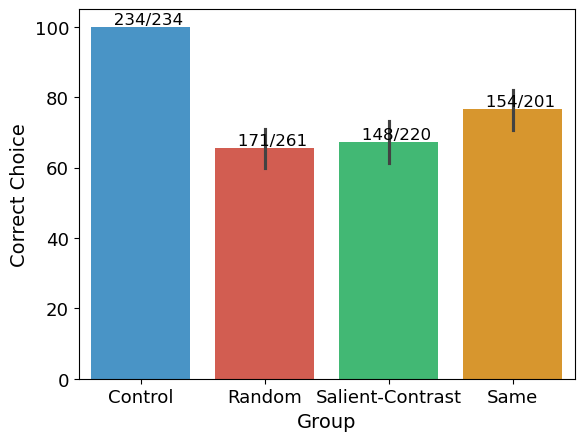

In [21]:
# choice to update
plot_simple_bar_plot(choice_results, 
                     'group', 
                     'choice_to_update', 
                     title='Choice to Update Percentage by Group', 
                     palette=colors_palette)

### Choices times

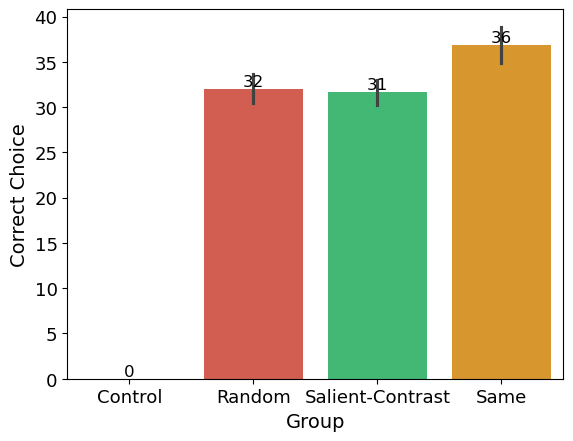

            level_1           level_2        U       p_value
0           Control            Random    117.0  2.822298e-91
1           Control  Salient-Contrast      0.0  1.584066e-87
2           Control              Same      NaN           NaN
3            Random  Salient-Contrast  27647.0  4.840532e-01
4            Random              Same      NaN           NaN
5  Salient-Contrast              Same      NaN           NaN


In [22]:
# choice time by group
plot_simple_bar_plot(choice_results, 
                     'group', 
                     'choice_time', 
                     title='Choice Time by Group', 
                     aggfunc='mean', 
                     from_total_agg=False,
                     estimator=lambda x: np.mean(x),  # mean seconds
                     palette=colors_palette,
                     errorbar='se',
                    #  x_val_names=group_names
)

mannwhitneyu_test(choice_results, 'choice_time', 'group')

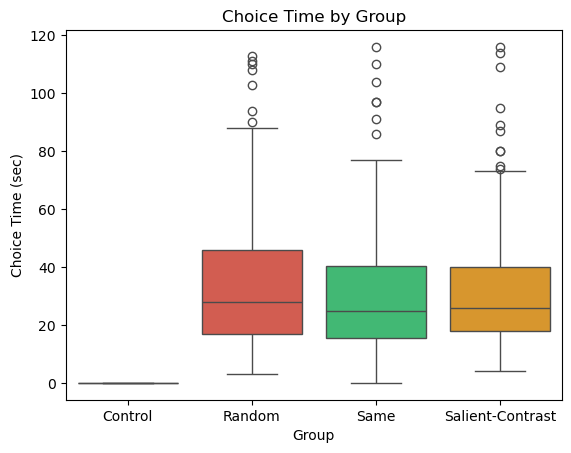

In [23]:


ax = sns.boxplot(
    data=choice_results[choice_results['choice_time'] < 120], # filter out extreme values
    x='group',
    y='choice_time',
    palette=colors_palette  # Use the predefined color palette for the box plot
)
plt.xlabel('Group')
plt.ylabel('Choice Time (sec)')
plt.title('Choice Time by Group')
ax.set_xticklabels(group_names)


plt.show()

### Trust the Agent

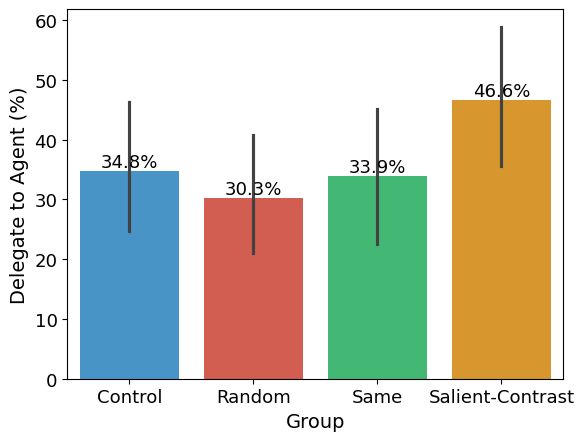

Mann-Whitney U Test Results for Delegate to by Group
            level_1           level_2       U   p_value
0           Control            Random  2740.5  0.282228
1           Control  Salient-Contrast  2221.5  0.923098
2           Control              Same  2158.5  0.457600
3            Random  Salient-Contrast  2321.5  0.979495
4            Random              Same  2271.0  0.674863
5  Salient-Contrast              Same  2550.5  0.068250


In [24]:
plot_simple_bar_plot(
    user_results,
    # user_results[(user_results['final_agent_name'] == sub_models_dict[7]['name']) | (user_results['final_agent_name'] == sub_models_dict[2]['name'])],
                     'group',
                     'trust_the_agent',
                     y_label='Delegate to Agent (%)',
                     x_label='Group',
                     title='Delegate to Agent',
                     aggfunc='sum',
                     x_val_names=group_names,
                     from_total_agg=False,
                     percentage_agg=True,
                     estimator=lambda x: np.mean(x) * 100,
                     palette=colors_palette,
                     errorbar=('ci', 95),
                     order=group_names,
                     save_path='images/delegate_to_agent_by_group.pdf'
                     )

print("Mann-Whitney U Test Results for Delegate to by Group")
mannwhitneyu_test(user_results, 'trust_the_agent', 'group', test_type='greater')

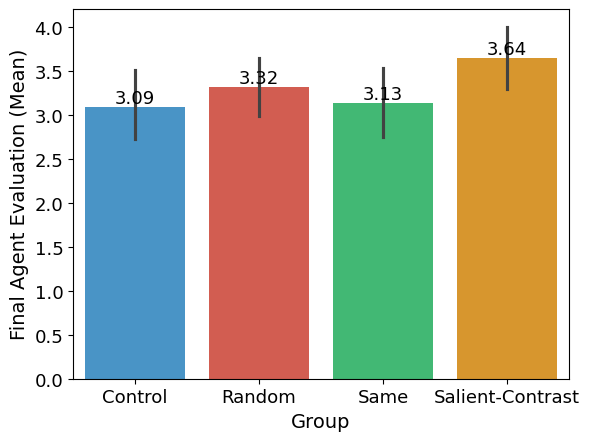

            level_1           level_2       U   p_value
0           Control            Random  2345.5  0.130683
1           Control  Salient-Contrast  1995.5  0.014471
2           Control              Same  2056.5  0.348729
3            Random  Salient-Contrast  2434.0  0.092773
4            Random              Same  2526.0  0.774061
5  Salient-Contrast              Same  2693.0  0.974463


In [25]:
plot_simple_bar_plot(
                     user_results,
                    # user_results[(user_results['final_agent_name'] == sub_models_dict[7]['name']) | (user_results['final_agent_name'] == sub_models_dict[2]['name'])],
                    x_col='group',
                    y_col='evaluate_final_agent',
                    x_label='Group',
                    y_label='Final Agent Evaluation (Mean)',
                    title='Final Agent Evaluation by Group',
                    aggfunc='mean',
                    from_total_agg=False,
                    only_total_agg=False,
                    percentage_agg=True,
                    estimator=lambda x: np.mean(x),
                    palette=colors_palette,
                    # x_val_names=group_names,
                    bar_label_fmt='%.2f',
                    order=group_names,
                    save_path='images/evaluate_ai_by_group.pdf'
)

import matplotlib.pyplot as plt



mannwhitneyu_test(user_results, 'evaluate_final_agent', 'group', test_type='less')


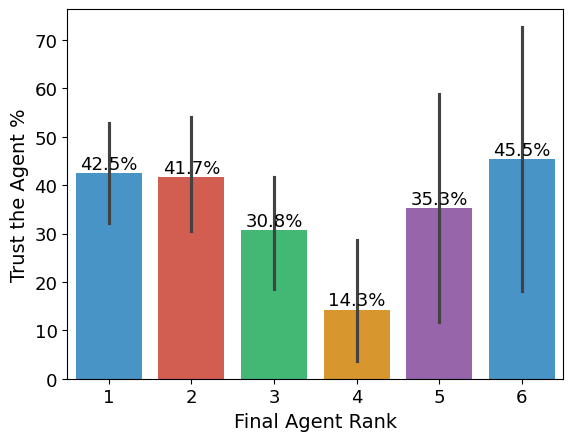

In [26]:
# models_names_order = [model_name for model_name in models_mean_scores.keys()]
# print(models_names_order)
plot_simple_bar_plot(
    user_results,
    x_col='final_agent_rank',
    y_col='trust_the_agent',
    figsize=(10, 6),
    estimator=lambda x: np.mean(x) * 100,
    palette=colors_palette,
    title='Trust the Final Agent by its Rank',
    x_label='Final Agent Rank',
    y_label='Trust the Agent %',
    percentage_agg=True
    # order=models_names_order #sorted(user_results['final_agent_name'].unique()),
)



setting x labels: ['Control', 'Random', 'Same', 'Salient-Contrast']


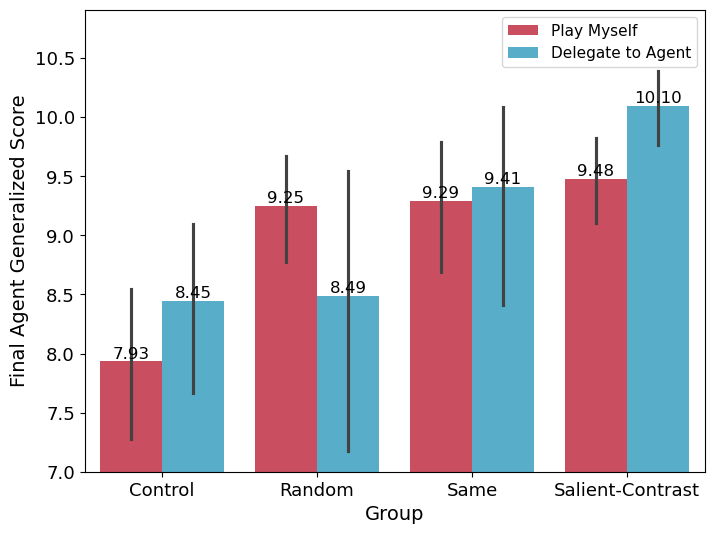

Mann-Whitney_u_test for group  Same
   level_1  level_2      U   p_value
0        0        1  403.5  0.340554
Mann-Whitney_u_test for group  Salient-Contrast
   level_1  level_2      U   p_value
0        0        1  449.0  0.006053
Mann-Whitney_u_test for group  Control
   level_1  level_2      U   p_value
0        0        1  461.0  0.152206
Mann-Whitney_u_test for group  Random
   level_1  level_2      U   p_value
0        0        1  640.0  0.642252


In [27]:
plot_df = user_results
plot_grouped_barplot(plot_df,
                     x_col='group',
                     y_col='final_agent_mean_score',
                     title="Final Agent Generalized Score by Group",
                     x_label='Group',
                     y_label='Final Agent Generalized Score',
                     hue='trust_the_agent',
                     hue_names=['Play Myself','Delegate to Agent'],
                     order=group_names,
                     x_val_names=group_names,
                    bar_label_fmt='%.2f',
                    percentage_agg=True,
                    aggfunc='mean',
                    estimator='mean',
                    palette=["#DC3A52", "#45B6DB"],  # light red and light blue
                    ylim_bottom=7,
                    save_path='images/final_agent_generalized_score_by_group_and_delegate_seperated.pdf'
)


for group in plot_df['group'].unique():
    print('Mann-Whitney_u_test for group ', group)
    mannwhitneyu_test(plot_df[plot_df['group'] == group], 'final_agent_mean_score', 'trust_the_agent', test_type='less')

setting x labels: ['Control', 'Random', 'Salient-Contrast', 'Same']


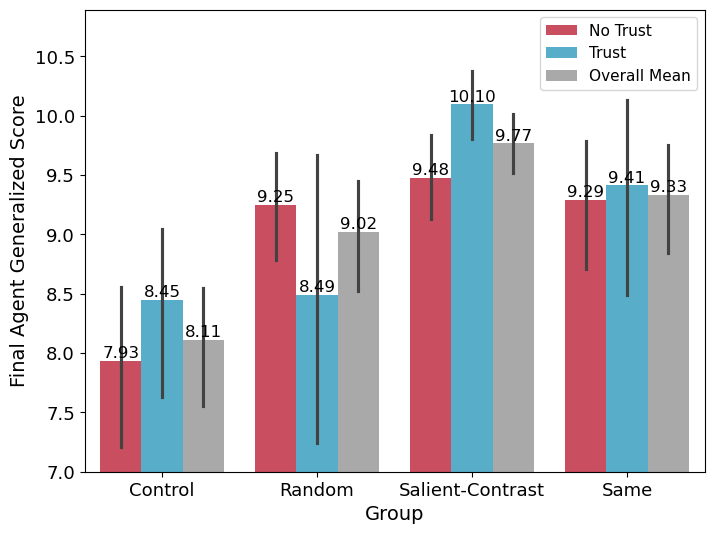

In [28]:

# Create a new dataframe to hold the data for the plot
# Data for 'No Trust' and 'Trust'
plot_df_trust = user_results[['group', 'final_agent_mean_score', 'trust_the_agent']].copy()
plot_df_trust['category'] = plot_df_trust['trust_the_agent'].apply(lambda x: 'Trust' if x == 1 else 'No Trust')

# Data for 'Overall Mean'
plot_df_overall = user_results[['group', 'final_agent_mean_score']].copy()
plot_df_overall['category'] = 'Overall Mean'

# Concatenate them
combined_df = pd.concat([plot_df_trust, plot_df_overall], ignore_index=True)


plot_grouped_barplot(combined_df,
                     x_col='group',
                     y_col='final_agent_mean_score',
                     title="Final Agent Generalized Score by Group",
                     x_label='Group',
                     y_label='Final Agent Generalized Score',
                     hue='category',
                     hue_title='Category',
                     hue_names=['No Trust', 'Trust', 'Overall Mean'],
                     order=sorted(user_results['group'].unique()),
                     bar_label_fmt='%.2f',
                     percentage_agg=True,
                     aggfunc='mean',
                     estimator='mean',
                     palette=["#DC3A52", "#45B6DB", "#A9A9A9"],  # light red, light blue, grey
                     ylim_bottom=7,
                     save_path='images/final_agent_generalized_score_by_group_with_overall_mean.pdf'
)


### Final agent distributions

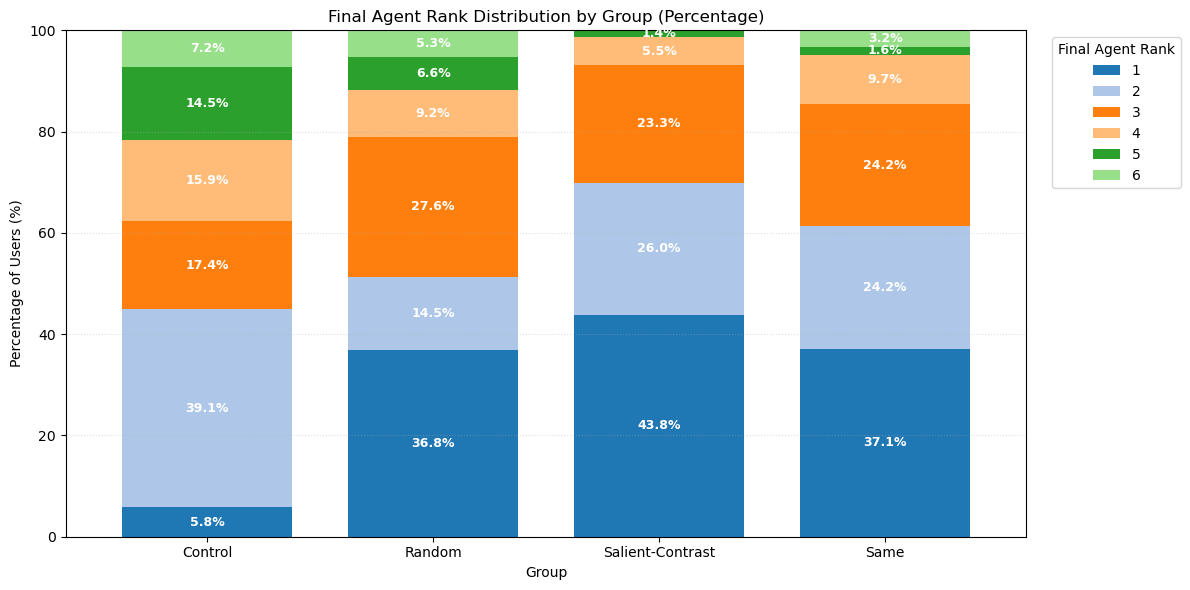

In [29]:
# Final Agent distrebution across Groups
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

similarity_col = 'group'              
rank_col = 'final_agent_rank'    

# Stable orders
rank_order = sorted([int(r) for r in user_results[rank_col].dropna().unique()])
group_order = sorted(user_results['group'].unique())

# Counts -> percentages per group
counts = pd.crosstab(user_results[similarity_col], user_results[rank_col]).reindex(index=group_order, columns=rank_order, fill_value=0)
pct = counts.div(counts.sum(axis=1), axis=0) * 100

# Plot stacked bars
fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('tab20', n_colors=len(rank_order))
pct.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.75)

# Axes formatting
ax.set_ylim(0, 100)
ax.set_ylabel('Percentage of Users (%)')
ax.set_xlabel('Group')
ax.set_title('Final Agent Rank Distribution by Group (Percentage)')
ax.set_xticklabels(group_order, rotation=0, ha='center')
ax.legend(title='Final Agent Rank', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', linestyle=':', alpha=0.4)

# Write percentage inside each stacked block
for container in ax.containers:
    for rect in container:
        h = rect.get_height()
        if h <= 0:
            continue
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_y() + h / 2,
            f'{h:.1f}%',
            ha='center',
            va='center',
            fontsize=9,
            fontweight='bold',
            color='white'
        )

plt.tight_layout()
plt.show()

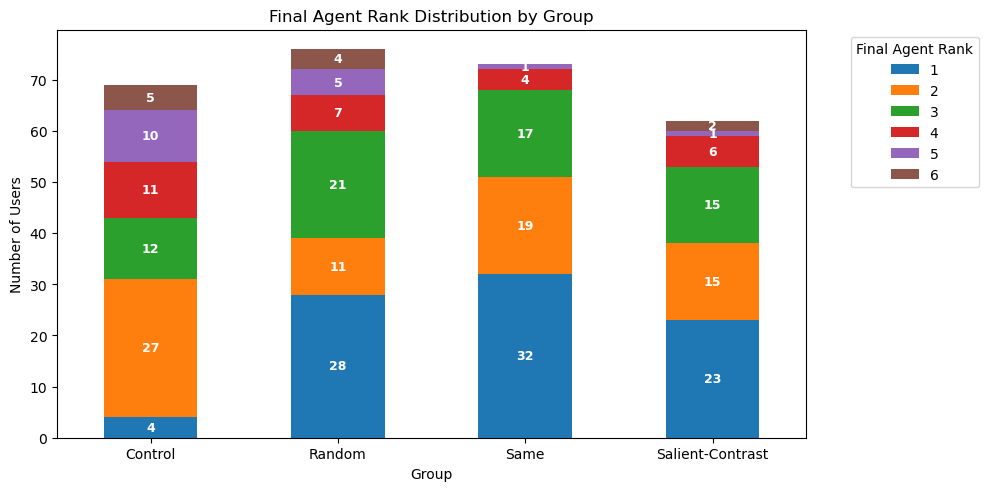

In [30]:
import matplotlib.pyplot as plt

# Get counts of final_agent_rank per group
agent_counts = user_results.groupby('group')['final_agent_rank'].value_counts().unstack(fill_value=0)

# Plot
agent_counts.plot(kind='bar', stacked=True, figsize=(10,6))
plt.xlabel('Group')
plt.ylabel('Number of Users')
plt.title('Final Agent Rank Distribution by Group')
plt.legend(title='Final Agent Rank', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
ax = plt.gca()
ax.set_xticklabels(group_names)
plt.xticks(rotation=0, ha='center')
# Annotate each block with the number of users for each final agent
for i, bar in enumerate(ax.containers):
    for rect in bar:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        xy=(rect.get_x() + rect.get_width() / 2, rect.get_y() + height / 2),
                        xytext=(0, 0),
                        textcoords="offset points",
                        ha='center', va='center', fontsize=9, fontweight='bold', color='white')
plt.show()

In [31]:
import pandas as pd

# Prepare orders
rank_order = sorted([int(r) for r in user_results['final_agent_rank'].dropna().unique()])
group_order = sorted(user_results['group'].unique())

# Counts and percentages
counts = pd.crosstab(user_results['group'], user_results['final_agent_rank']).reindex(index=group_order, columns=rank_order, fill_value=0)
pct = counts.div(counts.sum(axis=1), axis=0).mul(100).round(1)

print("Final Agent Rank Distribution by Group (%). Rows sum to 100.")
display(pct)

print("\nCounts per Group and Rank")
display(counts)

Final Agent Rank Distribution by Group (%). Rows sum to 100.


final_agent_rank,1,2,3,4,5,6
group,,,,,,
Control,5.8,39.1,17.4,15.9,14.5,7.2
Random,36.8,14.5,27.6,9.2,6.6,5.3
Salient-Contrast,43.8,26.0,23.3,5.5,1.4,0.0
Same,37.1,24.2,24.2,9.7,1.6,3.2



Counts per Group and Rank


final_agent_rank,1,2,3,4,5,6
group,,,,,,
Control,4,27,12,11,10,5
Random,28,11,21,7,5,4
Salient-Contrast,32,19,17,4,1,0
Same,23,15,15,6,1,2


Index(['user_id', 'episode', 'group', 'trust_the_agent', 'prev_agent',
       'updated_agent', 'prev_agent_mean_score', 'update_agent_mean_score',
       'prev_agent_feedback_score', 'updated_agent_feedback_score',
       'choice_to_update', 'correct_choice_generalized',
       'correct_choice_feedback', 'choice_time', 'improved_from_prev_feedback',
       'improved_from_prev_mean'],
      dtype='object')
[['0/81', '46/90', '56/77', '29/69'], ['153/153', '127/171', '127/143', '114/132']]
setting x labels: ['Control', 'Random', 'Same', 'Salient-Contrast']
[['0/81', '46/90', '56/77', '29/69'], ['153/153', '127/171', '127/143', '114/132']]
setting x labels: ['Control', 'Random', 'Same', 'Salient-Contrast']


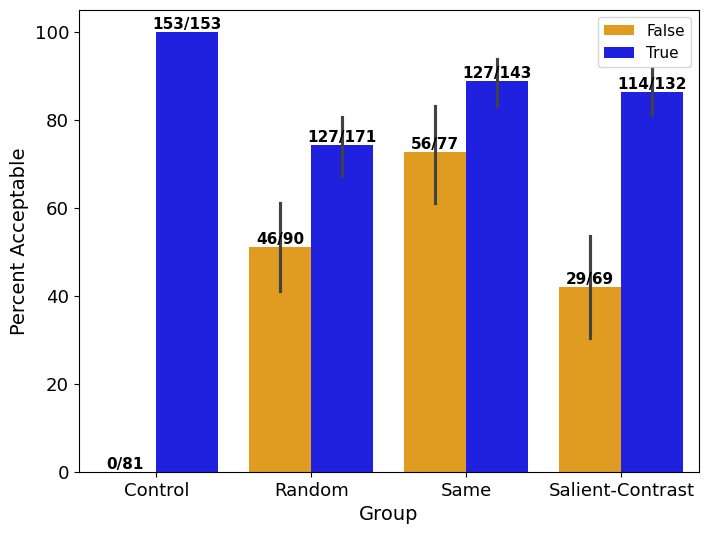

In [32]:
# trust by the number of improved from improved_from_prev_feedback
plot_df = choice_results.copy()
# plot_df['percent_acceptable'] = plot_df['number_of_accepts'] / plot_df['number_of_choices']
plot_grouped_barplot(plot_df,
                     x_col='group',
                     y_col='correct_choice_generalized',
                     hue='improved_from_prev_mean',
                     estimator=lambda x: np.mean(x) *100,
                    
                     palette=['orange', 'blue'],  #colors_palette,
                     x_label='Group',
                     y_label='Percent Acceptable',
                     from_total_agg=True,
                     x_val_names=group_names,
                     aggfunc='sum',
                     title='Percent Acceptable by Group and is the agent improved from the previous agent'
                     )

## Satisfection from the System

In [33]:
user_features = ['gender', 'age', 'education', 'familiar_with_AI', 'AI_1', 'AI_2', 'AI_3', 'AI_4', 'AI_5', 'ES_understandable', 'SS_2', 'ES_overwhelming', 'ES_feedback_contrebution', 'ES_helpful']
i = 12 # ES_feedback_contribution
plot_simple_bar_plot(
    df=user_results[user_results['group'] != '(0) Control'],
    y_col='trust_the_agent',
    x_col=user_features[i],
    x_val_names=None,
    palette=colors_palette,
    x_label=ai_questions_map[user_features[i]] if user_features[i] in ai_questions_map else user_features[i],
    y_label='Trust in Agent',
    title=f'Trust in Agent by {user_features[i]}',
    order=sorted([val for val in user_results[user_features[i]].unique() if pd.notna(val)]),
    debug_print=False
)



KeyError: 'ES_feedback_contrebution'

In [ ]:
user_results.columns

Index(['user_id', 'group', 'trust_the_agent', 'number_of_choices',
       'number_of_accepts', 'number_of_correct_choices_mean',
       'number_of_correct_choices_feedback', 'final_agent_mean_score',
       'final_agent_name', 'final_agent_rank', 'final_agent_final_part_score',
       'age', 'gender', 'education', 'familiar_with_AI',
       'evaluate_final_agent', 'ES_understandable', 'ES_overwhelming',
       'ES_feedback_related', 'ES_helpful', 'ES_combined'],
      dtype='object')

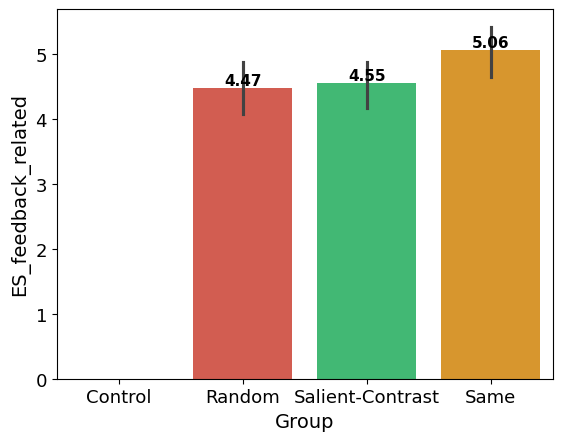

            level_1           level_2       U   p_value
0           Control            Random     NaN       NaN
1           Control  Salient-Contrast     NaN       NaN
2           Control              Same     NaN       NaN
3            Random  Salient-Contrast  2766.5  0.978396
4            Random              Same  1890.5  0.041921
5  Salient-Contrast              Same  1810.5  0.041583


In [ ]:
ES_questions = ['ES_understandable',
                'ES_overwhelming', 
                'ES_feedback_contrebution', 
                'ES_helpful',
                'ES_combined'
]


i = 2
plot_df = user_results[user_results['group'] != '(0) Control']
plot_simple_bar_plot(
    df=plot_df,
    y_col=ES_questions[i],
    x_col='group',
    # x_val_names=group_names[1:],
    palette=colors_palette,
    x_label='Group',
    y_label=ES_questions[i],
    title=f'{ES_questions[i]} Mean by Group',
    percentage_agg=True,
    estimator='mean',
    bar_label_fmt='%.2f',
    debug_print=False,
    order=sorted(list(plot_df['group'].unique()))
)

mannwhitneyu_test(plot_df, ES_questions[i], 'group')

In [ ]:
plot_df = user_results[user_results['group'] != '(0) Control'].copy()
plot_df['ES_overwhelming_reverse'] = (plot_df['ES_overwhelming'] -4) * -1 + 4
plot_df['ES_total'] = plot_df[['ES_understandable', 'ES_overwhelming_reverse', 'ES_feedback_contribution', 'ES_helpful']].sum(axis=1)
plot_df['ES_combined'] = plot_df['ES_total'] / 4
plot_df['ES_combined'].describe()

count    280.000000
mean       3.630357
std        2.396415
min        0.000000
25%        1.000000
50%        4.500000
75%        5.500000
max        7.000000
Name: ES_combined, dtype: float64

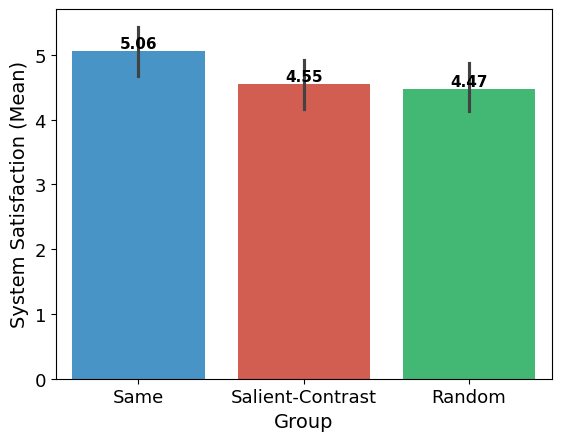

Mann-Whitney U Test Results for System Satisfaction (Mean) by Group
            level_1           level_2       U   p_value
0            Random  Salient-Contrast  2766.5  0.978396
1            Random              Same  1890.5  0.041921
2  Salient-Contrast              Same  1810.5  0.041583


In [ ]:
plot_df = user_results[user_results['group'] != 'Control'].copy()
plot_df['ES_overwhelming_reverse'] = (plot_df['ES_overwhelming'] -4) * -1 + 4
plot_df['ES_total'] = plot_df[['ES_understandable', 'ES_overwhelming_reverse', 'ES_feedback_contribution', 'ES_helpful']].sum(axis=1)
plot_df['ES_combined'] = plot_df['ES_total'] / 4
plot_simple_bar_plot(
    df=plot_df,
    y_col='ES_feedback_contribution',
    x_col='group',
    # x_val_names=group_names[1:],
    palette=colors_palette,
    x_label='Group',
    y_label='System Satisfaction (Mean)',
    title=f'System Satisfaction (Mean) by Group',
    percentage_agg=True,
    estimator='mean',
    bar_label_fmt='%.2f',
    order=plot_df['group'].unique(),
    debug_print=False,
    # save_path='images/System_satisfaction_mean_by_group.pdf'
)

print("Mann-Whitney U Test Results for System Satisfaction (Mean) by Group")
mannwhitneyu_test(plot_df, 'ES_feedback_contribution', 'group', test_type='two-sided')

In [ ]:
import pingouin as pg

# Create a copy to avoid SettingWithCopyWarning
plot_df = user_results[user_results['group'] != '(0) Control'].copy()

# Reverse code the 'ES_overwhelming' score
plot_df['ES_overwhelming_reverse'] = (plot_df['ES_overwhelming'] - 4) * -1 + 4

# Select the columns for Cronbach's alpha calculation
# The user mentioned: ES_understanding, ES_overwhalming_reverse, ES_feedback_contribution and ES_useful
# The correct column names are: ES_understandable, ES_overwhelming_reverse, ES_feedback_contribution, ES_helpful
alpha_cols = plot_df[['ES_understandable', 'ES_overwhelming_reverse', 'ES_feedback_contribution', 'ES_helpful']]

# Drop rows with any NaN values in these columns
alpha_cols = alpha_cols.dropna()

# Calculate Cronbach's alpha
cronbach_alpha = pg.cronbach_alpha(data=alpha_cols)

print("Cronbach's alpha for the satisfaction questions:")
print(cronbach_alpha)

Cronbach's alpha for the satisfaction questions:
(0.8252217272203431, array([0.783, 0.861]))


### Agent diff in Score

### User performance vs Agent score - Final Part

### Predicting models

In [ ]:
# predict trust_the_agent with all other parameters of user_results, using LR and Random Forest
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Target and dataset
target = 'trust_the_agent'
df = user_results.copy()

# Columns to exclude from features
ban_cols = [
    target,
    'user_id',
    'number_of_choices',
    'number_of_accepts',
    'number_of_correct_choices_mean',
    'number_of_correct_choices_feedback',
    'number_of_improved_choices',
    'final_improved',
    'final_agent_mean_score',  # old final_agent_score
    'final_agent_final_part_score',
    'user_performance',
    'age',
]

X_col = df.columns.difference(ban_cols)
print("X features:", X_col.tolist())
X = df.loc[:, X_col]
y = df[target]

# Prepare data (drop rows with missing target)
X = X.dropna()
y = y.loc[X.index]

# Encode categorical variables if needed
X_encoded = pd.get_dummies(X, drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

X features: ['ES_combined', 'ES_feedback_related', 'ES_helpful', 'ES_overwhelming', 'ES_understandable', 'education', 'evaluate_final_agent', 'familiar_with_AI', 'final_agent_name', 'final_agent_rank', 'gender', 'group']
Logistic Regression Accuracy: 0.6744186046511628
              precision    recall  f1-score   support

           0       0.68      0.84      0.75        25
           1       0.67      0.44      0.53        18

    accuracy                           0.67        43
   macro avg       0.67      0.64      0.64        43
weighted avg       0.67      0.67      0.66        43

Random Forest Accuracy: 0.6511627906976745
              precision    recall  f1-score   support

           0       0.67      0.80      0.73        25
           1       0.62      0.44      0.52        18

    accuracy                           0.65        43
   macro avg       0.64      0.62      0.62        43
weighted avg       0.65      0.65      0.64        43



In [ ]:
import pandas as pd


# Get feature names and coefficients from the trained LogisticRegression model
feature_names = X_encoded.columns
feature_importances = lr.coef_[0]

# Create a DataFrame for feature importances
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})

# Sort by absolute importance
feat_imp_df = feat_imp_df.reindex(feat_imp_df['importance'].abs().sort_values(ascending=False).index)

print(list(feat_imp_df['feature']))
print(list(feat_imp_df['importance']))

['final_agent_name_OnlyBlueLL_0625', 'group_Salient-Contrast', 'evaluate_final_agent', 'group_Same', 'gender', 'familiar_with_AI', 'final_agent_name_OnlyGreenLL_0429', 'final_agent_name_AllColorsLL1_0526', 'ES_helpful', 'final_agent_name_NoRedLH1_0612', 'ES_feedback_related', 'final_agent_name_OnlyBlueLH_0706', 'ES_overwhelming', 'ES_combined', 'final_agent_rank', 'ES_understandable', 'education']
[-0.9200362278033939, 0.6271030643216612, 0.6000342896766355, 0.5679363712320872, 0.43866452647389537, -0.380502721876593, 0.30140840615718545, 0.28360051661036634, 0.2503916726077079, 0.151521176431187, -0.0976940694128545, -0.09712087610310394, -0.08295484951268804, 0.0593542756990446, -0.02653515417211146, -0.021212067947867938, -0.020200251731333534]


In [ ]:
import pandas as pd

feature_importances = rf.feature_importances_
# Get feature names from X_encoded
feature_names = X_encoded.columns

# Create a DataFrame for feature importances
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})

# Sort by absolute importance
feat_imp_df = feat_imp_df.reindex(feat_imp_df['importance'].abs().sort_values(ascending=False).index)

print(list(feat_imp_df['feature']))
print(list(feat_imp_df['importance']))


['evaluate_final_agent', 'ES_combined', 'familiar_with_AI', 'ES_feedback_related', 'education', 'ES_overwhelming', 'ES_understandable', 'ES_helpful', 'final_agent_rank', 'gender', 'group_Salient-Contrast', 'group_Same', 'final_agent_name_NoRedLH1_0612', 'final_agent_name_OnlyBlueLL_0625', 'final_agent_name_OnlyBlueLH_0706', 'final_agent_name_AllColorsLL1_0526', 'final_agent_name_OnlyGreenLL_0429']
[0.196669859971172, 0.1284854899041983, 0.09537162444760364, 0.07536083516964898, 0.07157253661335435, 0.06772213350218496, 0.06763748813739344, 0.0662242262208238, 0.05187046338686731, 0.048924753024014826, 0.038781485196781984, 0.02874137767547444, 0.018771413235176636, 0.017592391176973757, 0.017166357638137633, 0.006987797725720421, 0.002119766974473546]


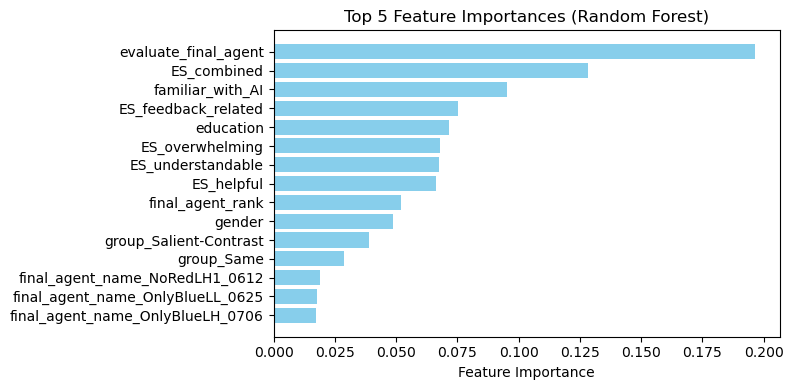

In [ ]:
import matplotlib.pyplot as plt

# Use feat_imp_df from cell 95 (Random Forest feature importances)
top5 = feat_imp_df.head(15)

plt.figure(figsize=(8, 4))
plt.barh(top5['feature'], top5['importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Top 5 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()  # Highest importance at top
plt.tight_layout()
plt.show()

### Predict users Choices

In [ ]:
choice_results.columns

Index(['user_id', 'episode', 'group', 'trust_the_agent', 'prev_agent',
       'updated_agent', 'prev_agent_mean_score', 'update_agent_mean_score',
       'prev_agent_feedback_score', 'updated_agent_feedback_score',
       'choice_to_update', 'correct_choice_generalized',
       'correct_choice_feedback', 'choice_time', 'improved_from_prev_feedback',
       'improved_from_prev_mean'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Prepare data for prediction
target = 'choice_to_update'
df = choice_results.copy()
ban_cols = [
    target,
    'user_id',
    'final_agent',
    'final_agent_mean_score',
    'correct_choice_generalized',
    'correct_choice_feedback',
]
X_col = df.columns.difference(ban_cols)
X = df.loc[:, X_col]
y = df[target]

# Drop rows with missing target
X = X.dropna()
y = y.loc[X.index]

# Encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.8415300546448088
              precision    recall  f1-score   support

           0       0.67      0.39      0.49        36
           1       0.86      0.95      0.91       147

    accuracy                           0.84       183
   macro avg       0.77      0.67      0.70       183
weighted avg       0.83      0.84      0.82       183

Random Forest Accuracy: 0.819672131147541
              precision    recall  f1-score   support

           0       0.55      0.47      0.51        36
           1       0.88      0.90      0.89       147

    accuracy                           0.82       183
   macro avg       0.71      0.69      0.70       183
weighted avg       0.81      0.82      0.81       183



In [ ]:
y_test.value_counts()

choice_to_update
1    147
0     36
Name: count, dtype: int64

In [ ]:
import pandas as pd


# Get feature names and coefficients from the trained LogisticRegression model
feature_names = X_encoded.columns
feature_importances = lr.coef_[0]

# Create a DataFrame for feature importances
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})

# Sort by absolute importance
feat_imp_df = feat_imp_df.reindex(feat_imp_df['importance'].abs().sort_values(ascending=False).index)

print(list(feat_imp_df['feature']))
print(list(feat_imp_df['importance']))

['group_Random', 'group_Salient-Contrast', 'group_Same', 'prev_agent_OnlyBlueLH_0706', 'updated_agent_AllColorsLL1_0526', 'updated_agent_OnlyBlueLL_0625', 'prev_agent_OnlyBlueLL_0625', 'prev_agent_NoRedLH1_0612', 'updated_agent_OnlyBlueLH_0706', 'improved_from_prev_feedback', 'prev_agent_OnlyGreenLL_0429', 'prev_agent_mean_score', 'update_agent_mean_score', 'prev_agent_AllColorsLL1_0526', 'improved_from_prev_mean', 'updated_agent_NoRedLH1_0612', 'updated_agent_OnlyGreenLL_0429', 'episode', 'updated_agent_feedback_score', 'trust_the_agent', 'prev_agent_feedback_score', 'choice_time']
[-2.7787058041702606, -2.620637575363172, -2.027401389340992, -0.814005397642962, -0.7824151492360828, -0.7682090164079975, 0.7228017577881419, -0.6873433048264008, 0.6307726143243734, 0.41521798466287124, -0.2813018068325225, -0.20650582821391245, 0.18957808948752275, 0.1879981227978914, 0.14974273352193396, 0.06971395250468572, 0.06289253287761287, -0.05533374015210529, -0.0477623177435026, -0.02423516796